In [2]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.optimize as spop

In [10]:
#importing data

symbols= ['RELIANCE.NS','HDFCBANK.NS','ICICIBANK.NS','HDFCBANK.NS','INFY.NS','ITC.NS','TCS.NS','HINDUNILVR.NS','SBIN.NS','BHARTIARTL.NS']
df = yf.download(symbols, interval='1d')['Close']
returns_df = df.pct_change(1)
#prices_df = yf.download(tickers, start, end)['Adj Close']

[*********************100%***********************]  9 of 9 completed


In [16]:
returns =returns_df.dropna()
returns

,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,
2002-08-13,0.003306,0.008103,0.033383,-0.000372,0.000279,0.016900,0.006640,-0.002374,-0.013539
2002-08-14,-0.001648,-0.015130,0.006634,-0.014892,-0.021524,0.018687,-0.016492,-0.005408,-0.068943
2002-08-15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2002-08-16,0.034653,0.009602,0.044126,0.014361,0.016316,0.013486,0.017816,-0.000217,-0.002400
2002-08-19,0.028708,0.003329,-0.012624,0.012668,0.005403,-0.011876,0.010091,0.000653,-0.024742
...,...,...,...,...,...,...,...,...,...
2024-08-05,-0.018811,-0.026158,0.008672,-0.020016,-0.038052,-0.006338,-0.034682,-0.042696,-0.029885
2024-08-06,-0.015112,-0.009005,0.012574,-0.004904,-0.000457,0.000617,0.006028,-0.017187,0.003887
2024-08-07,-0.001247,0.013927,-0.002182,0.004799,0.023157,0.013058,0.006027,0.013727,0.007012


In [24]:
#calculating the return vector and the covariance matrix
cov = returns.cov()*252
r = np.array(((1+returns_df).prod())**(252/len(returns_df)) - 1)
e = np.ones(len(r))

In [26]:
cov

,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,SBIN.NS,TCS.NS
BHARTIARTL.NS,0.133773,0.034461,0.020980,0.050532,0.027951,0.025328,0.050397,0.043861,0.035146
HDFCBANK.NS,0.034461,0.086571,0.022597,0.064371,0.028480,0.027996,0.043363,0.051758,0.028776
HINDUNILVR.NS,0.020980,0.022597,0.073421,0.027608,0.019524,0.025190,0.025556,0.023954,0.021983
ICICIBANK.NS,0.050532,0.064371,0.027608,0.148053,0.037817,0.035105,0.067343,0.086814,0.044450
INFY.NS,0.027951,0.028480,0.019524,0.037817,0.096739,0.019393,0.033121,0.028569,0.053149
ITC.NS,0.025328,0.027996,0.025190,0.035105,0.019393,0.076476,0.031228,0.033733,0.022959
RELIANCE.NS,0.050397,0.043363,0.025556,0.067343,0.033121,0.031228,0.181885,0.053534,0.104862
SBIN.NS,0.043861,0.051758,0.023954,0.086814,0.028569,0.033733,0.053534,0.129035,0.031064
TCS.NS,0.035146,0.028776,0.021983,0.044450,0.053149,0.022959,0.104862,0.031064,0.337024


In [27]:
#defining the investable universe
icov = np.linalg.inv(cov)
h = np.matmul(e, icov)
g = np.matmul(r, icov)
a = np.sum(e*h)
b = np.sum(e*g)
c = np.sum(r*g)
d = a*c - b**2

In [28]:
#minimum variance and tangency portfolio
mvp = h/a
mvp_return = b/a
mvp_risk = 1/a**(1/2)
tangency = g/b 
tangency_return = c/b
tangency_risk = c**(1/2)/b

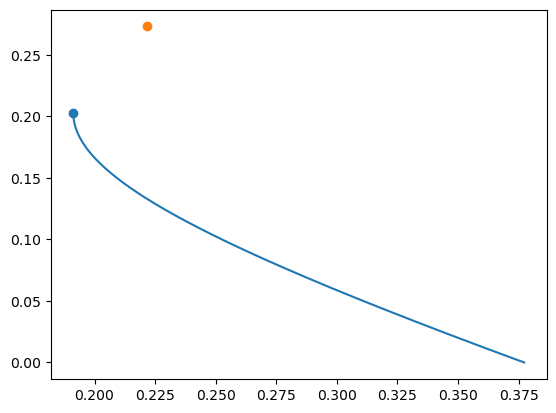

In [29]:
#plotting the efficient portfolio frontier
exp_returns = np.arange(0, 0.2001, 0.001)
risk = ((a*exp_returns**2 - 2*b*exp_returns + c)/d)**(1/2)
plt.scatter(mvp_risk, mvp_return)
plt.scatter(tangency_risk, tangency_return)
plt.plot(risk, exp_returns)

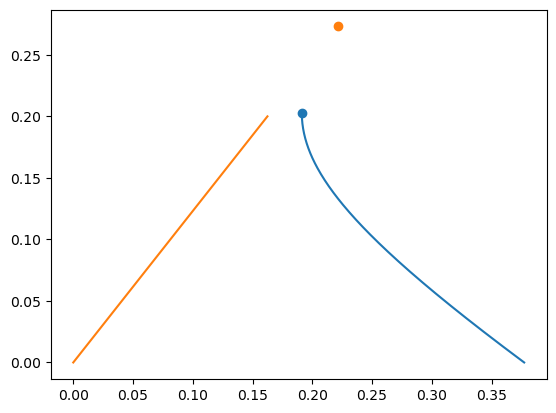

In [30]:
#plotting the securities market line
CAL_slope = 1/c**(1/2)
CAL_risk = exp_returns*CAL_slope
plt.plot(risk, exp_returns)
plt.plot(CAL_risk, exp_returns)
plt.scatter(mvp_risk, mvp_return)
plt.scatter(tangency_risk, tangency_return)

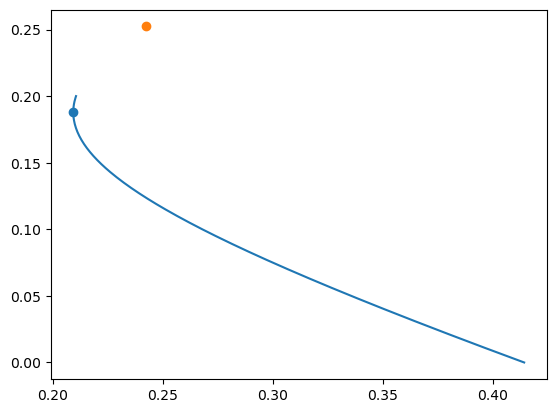

In [23]:
#solving the target return problem
target_return = 0.12
if target_return < mvp_return:
    optimal_portfolio = mvp
    optimal_return = mvp_return
    optimal_risk = mvp_risk
else:
    l = (c - b*target_return)/d
    m = (a*target_return - b)/d
    optimal_portfolio = l*h + m*g
    optimal_return = np.sum(optimal_portfolio*r)
    optimal_risk = ((a*optimal_return**2 - 2*b*optimal_return + c)/d)**(1/2)
plt.plot(risk, exp_returns)
plt.scatter(optimal_risk, optimal_return)
plt.scatter(tangency_risk, tangency_return)